<a href="https://colab.research.google.com/github/eudoalah-prog/Ass-2/blob/main/Ass_(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

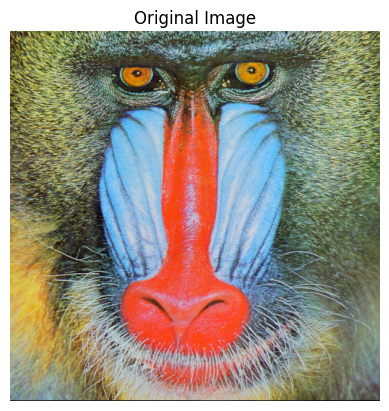

512
DCT coefficients (first 8x8 block):
[[ 6.3513e+02  8.1610e+01 -7.4660e+01  3.3910e+01 -3.4880e+01 -2.6590e+01
   3.5660e+01 -6.4000e-01]
 [-2.2150e+01  3.3230e+01  7.7730e+01  9.5850e+01  5.1640e+01 -3.0060e+01
  -7.7760e+01  3.1520e+01]
 [ 2.5900e+00 -3.1750e+01 -5.6720e+01  1.5580e+01  8.3430e+01  5.6710e+01
   3.6000e+00 -2.3780e+01]
 [ 2.0680e+01  2.6620e+01  6.8600e+00  7.7600e+00 -1.6000e-01  2.6610e+01
   4.3340e+01  4.0470e+01]
 [ 2.8130e+01 -1.6700e+00 -1.7210e+01  1.8980e+01 -4.3800e+00 -3.5600e+00
   3.2000e+00 -7.9700e+00]
 [ 8.2000e+00 -1.6440e+01 -2.6730e+01  1.1570e+01 -2.5500e+00 -3.6500e+00
   2.1800e+01 -1.4240e+01]
 [-1.0410e+01  4.9200e+00 -5.9000e+00  8.5800e+00  9.6800e+00 -7.8600e+00
   4.9700e+00  2.1140e+01]
 [-1.5000e-01 -1.0020e+01  8.1000e-01 -4.0800e+00  9.2800e+00  7.8200e+00
  -1.8270e+01  7.6500e+00]]


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.fftpack import dct

def prepare_image(path, space='YCrCb'):
    img_bgr = cv2.imread(path)
    if space.upper() == 'YCRCB':
        img_converted = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2YCrCb)
    elif space.upper() == 'LAB':
        img_converted = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2Lab)
    else:
        img_converted = img_bgr

    plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
    plt.title("Original Image")
    plt.axis('off')
    plt.show()
    return img_converted

def apply_dct8x8(block):
    return dct(dct(block.T, norm='ortho').T, norm='ortho')

def apply_dct_to_image(y_channel):
    h, w = y_channel.shape

    print(h)
    # Padding
    pad_h = (8 - (h % 8)) % 8
    pad_w = (8 - (w % 8)) % 8
    new_h = h + pad_h
    new_w = w + pad_w
    padded = np.zeros((new_h, new_w))
    padded[:h, :w] = y_channel

    # DCT on 8x8 blocks 
    for i in range (0, new_h, 8):
        for j in range (0, new_w, 8):
            block = padded[i:i+8, j:j+8]
            dct_block = apply_dct8x8(block)
            padded[i:i+8, j:j+8] = dct_block

    return padded

converted = prepare_image('./images/baboon.png', 'YCrCb')
y_channel = converted[:, :, 0].astype(float)

dct_full = apply_dct_to_image(y_channel)

print("DCT coefficients (first 8x8 block):")
print(np.round(dct_full[0:8, 0:8], 2))